<div align="center">

###  Visualization & Insights

**Creating visualizations to understand product trends and summarizing key business insights.**

**Workflow:** Load Data → Explore Metrics → Create Charts → Analyze Trends → Identify Patterns → Generate Business Insights

</div>

<div align="center">

### Libraries

**Python libraries used for visualization and business insights.**



</div>

In [3]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

notebook_dir = Path.cwd()
csv_candidates = [
    notebook_dir / "Data/shopsy_db/shopsy_kitchen_products_cleaned.csv",
    notebook_dir.parent / "Data/shopsy_db/shopsy_kitchen_products_cleaned.csv",
    Path("Data/shopsy_db/shopsy_kitchen_products_cleaned.csv")
]
csv_path = next((path for path in csv_candidates if path.exists()), None)

if csv_path is None:
    raise FileNotFoundError("Cleaned CSV not found in the Data/shopsy_db folder.")

df = pd.read_csv(csv_path)
for column in ["Price", "Discount", "Rating", "Reviews"]:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df["Brand"] = df["Brand"].fillna("Unknown")
df["Material"] = df["Material"].fillna("Unknown")
df["Product_Name"] = df["Product_Name"].fillna("Unknown")

sns.set_theme(style="whitegrid", palette="deep")
print(f"Loaded {len(df):,} products from {csv_path}.")
display(df.head())

Loaded 29 products from d:\DS\Data engineering courses\shopsy_home_kitchen_project\Data\shopsy_db\shopsy_kitchen_products_cleaned.csv.


,Product_Name,Price,Discount,Rating,Reviews,Brand,Capacity,Material,Product_URL
0,Qtrix Pack of 8 Plastic Grocery Container - 50...,300,69,4.4,104.0,Qtrix,"500 ml, 1100 ml, 1500 ml",Plastic,https://www.shopsy.in/qtrix-pack-8-plastic-gro...
1,AneriDEALS Pack of 24 Plastic Grocery Containe...,423,78,4.1,34.0,AneriDEALS,"250 ml, 350 ml, 650 ml, 1200 ml, 1000 ml",Plastic,https://www.shopsy.in/anerideals-pack-24-plast...
2,BELIZZI Pack of 6 Plastic Fridge Container - 1...,257,74,4.1,272.0,BELIZZI,"1500 ml, 500 ml, 1000 ml",Plastic,https://www.shopsy.in/belizzi-pack-6-plastic-f...
3,SHAN Pack of 2 Ceramic Pickle Jar - 500 ml Green,345,50,4.3,NaN,SHAN,500 ml,Ceramic,https://www.shopsy.in/shan-pack-2-ceramic-pick...
4,"RK Pack of 5 Steel Cookie Jar - 300 ml, 500 ml...",383,76,4.1,83.0,RK,"300 ml, 500 ml, 750 ml, 1150 ml, 1650 ml, 375 ...",Steel,https://www.shopsy.in/rk-pack-5-steel-cookie-j...


<div align="center">

###  Key Business Insights

**Summarizing the main findings from product price, rating, discount, and customer review analysis.**

</div>

In [2]:
top = df.sort_values(["Rating", "Reviews"], ascending=False).head(5)
print("Top-rated products:")
display(top[["Product_Name", "Brand", "Price", "Rating", "Reviews"]])

print("\nKey insights:")
print(f"- Average price: INR {df['Price'].mean():.2f}")
print(f"- Average rating: {df['Rating'].mean():.2f} / 5")
print(f"- Average discount: {df['Discount'].mean():.2f}%")
print(f"- Most reviewed product: {df.loc[df['Reviews'].idxmax(), 'Product_Name']}")

Top-rated products:


,Product_Name,Brand,Price,Rating,Reviews
0,Qtrix Pack of 8 Plastic Grocery Container - 50...,Qtrix,300,4.4,104.0
14,SKYHEART Pack of 8 Plastic Grocery Container -...,SKYHEART,486,4.4,61.0
11,Flatkitch Pack of 6 Plastic Grocery Container ...,Flatkitch,241,4.4,1.0
15,VAD Pack of 2 Glass Grocery Container - 1000 m...,VAD,169,4.3,43.0
8,Veksin Pack of 6 Plastic Grocery Container - 1...,Veksin,497,4.3,23.0



Key insights:
- Average price: INR 333.69
- Average rating: 4.10 / 5
- Average discount: 61.62%
- Most reviewed product: koktailkitchan Pack of 12 Plastic Grocery Container - 500 ml Black


<div align="center">

###  Average Price by Brand

**Comparing the average product price across different brands.**

</div>

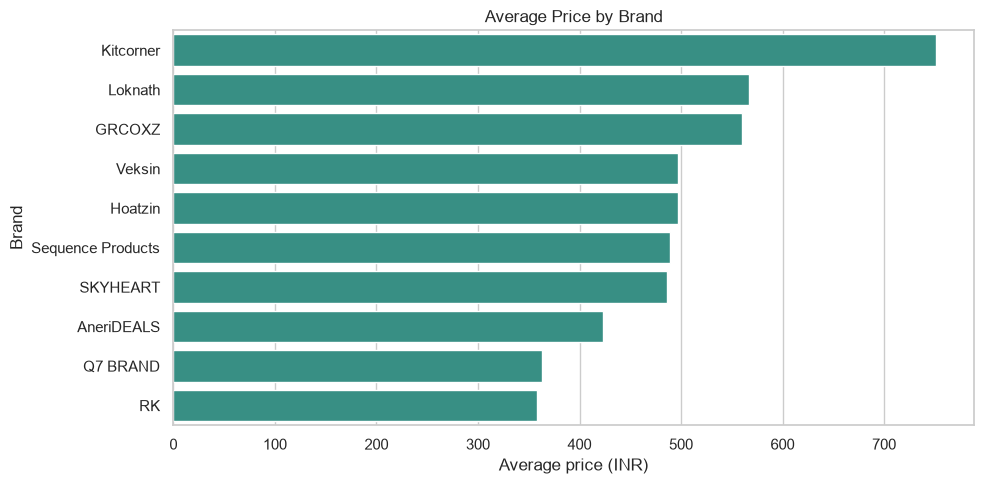

In [ ]:

brand_price = (
    df.groupby("Brand", as_index=False)["Price"]
    .mean()
    .sort_values("Price", ascending=False)
    .head(10)
)
plt.figure(figsize=(10, 5))
sns.barplot(data=brand_price, x="Price", y="Brand", color="#2a9d8f")
plt.title("Average Price by Brand")
plt.xlabel("Average price (INR)")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

<div align="center">

### Discount Distribution

**Visualizing the distribution of product discounts to understand pricing patterns.**

</div>

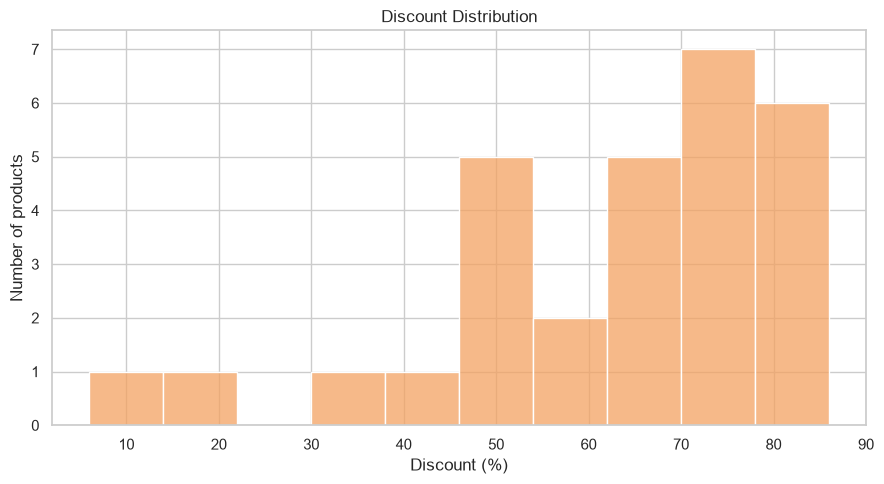

In [ ]:
# Chart 2: Discount distribution
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="Discount", bins=10, color="#f4a261", edgecolor="white")
plt.title("Discount Distribution")
plt.xlabel("Discount (%)")
plt.ylabel("Number of products")
plt.tight_layout()
plt.show()

<div align="center">

###  Chart 3: Rating Distribution

**Visualizing product ratings to understand customer satisfaction patterns.**

</div>

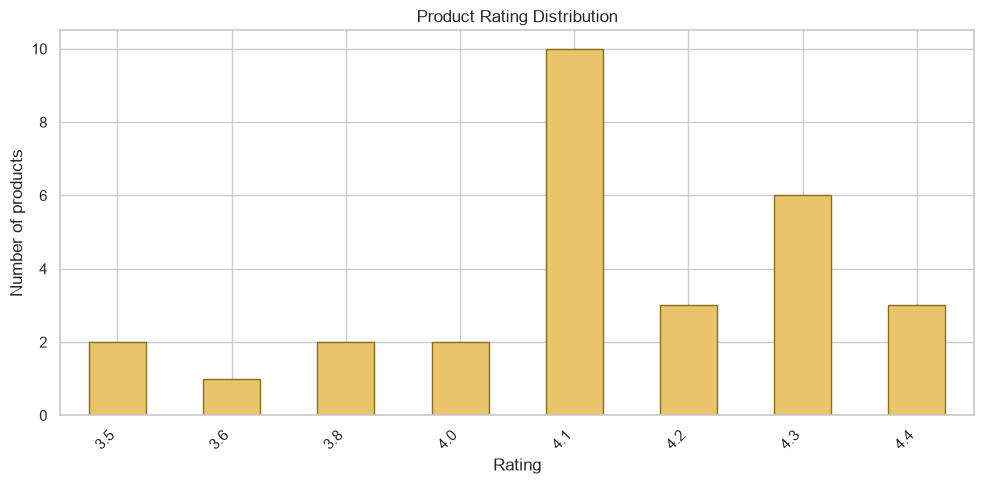

In [ ]:

rating_counts = df["Rating"].round(1).value_counts().sort_index()
plt.figure(figsize=(10, 5))
rating_counts.plot(kind="bar", color="#e9c46a", edgecolor="#8a6d1d")
plt.title("Product Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of products")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

<div align="center">

###  Rating vs. Review Count

**Analyzing the relationship between product ratings and customer review counts.**

</div>

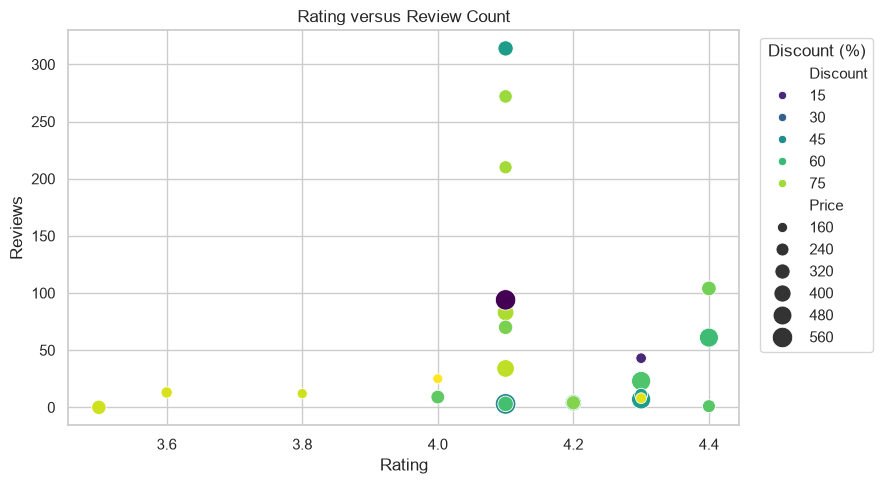

In [ ]:

scatter_df = df.dropna(subset=["Rating", "Reviews"])
plt.figure(figsize=(9, 5))
sns.scatterplot(data=scatter_df, x="Rating", y="Reviews", hue="Discount", size="Price", sizes=(40, 220), palette="viridis")
plt.title("Rating versus Review Count")
plt.xlabel("Rating")
plt.ylabel("Reviews")
plt.legend(title="Discount (%)", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

<div align="center">

###  Review Count by Brand

**Comparing customer review counts across brands to identify highly engaged brands.**

</div>

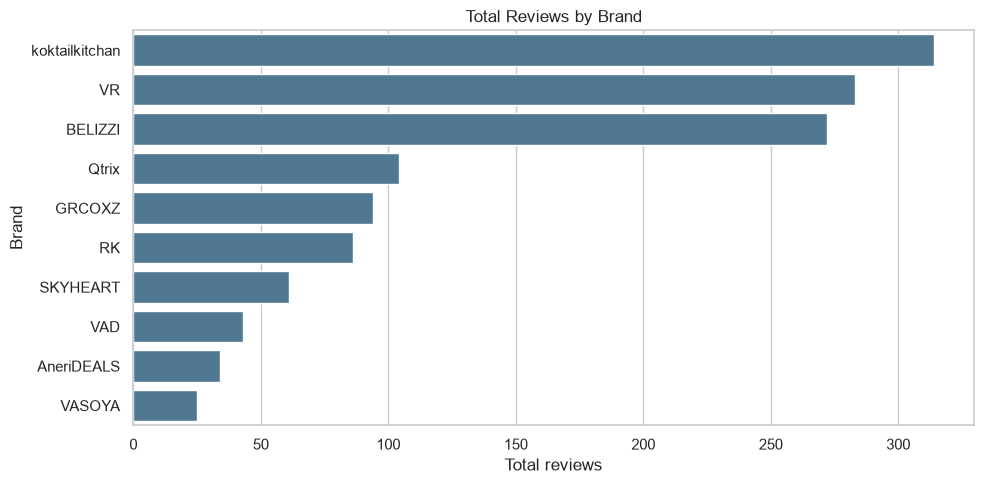

In [ ]:

brand_reviews = (
    df.groupby("Brand", as_index=False)["Reviews"]
    .sum()
    .sort_values("Reviews", ascending=False)
    .head(10)
)
plt.figure(figsize=(10, 5))
sns.barplot(data=brand_reviews, x="Reviews", y="Brand", color="#457b9d")
plt.title("Total Reviews by Brand")
plt.xlabel("Total reviews")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

<div align="center">

### Top Products by Review Count

**Identifying the products with the highest number of customer reviews.**

</div>

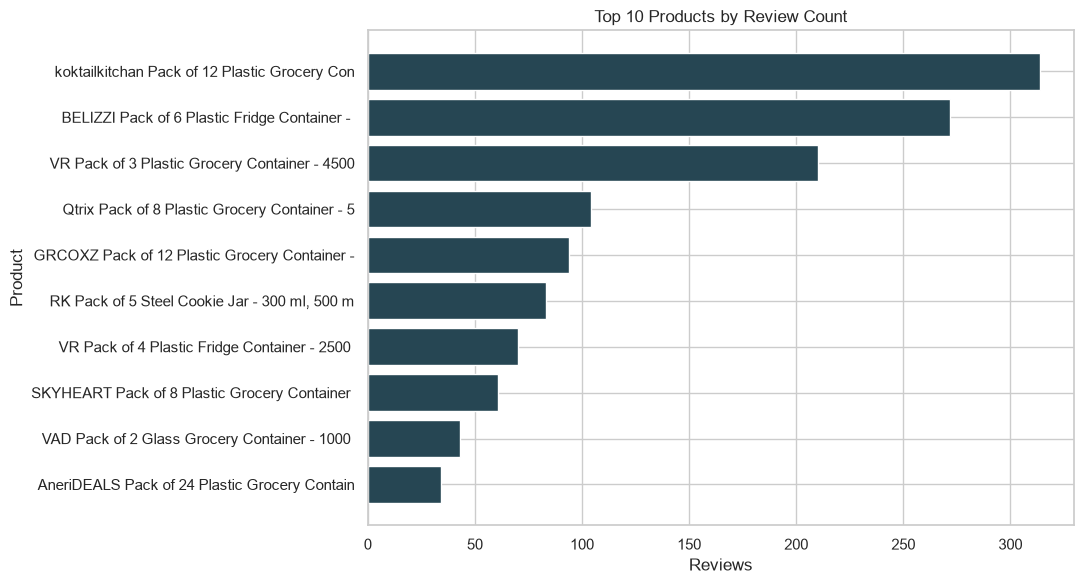

In [ ]:
review_data = df.dropna(subset=["Reviews"]).nlargest(10, "Reviews").sort_values("Reviews")
plt.figure(figsize=(11, 6))
plt.barh(review_data["Product_Name"].str.slice(0, 45), review_data["Reviews"], color="#264653")
plt.title("Top 10 Products by Review Count")
plt.xlabel("Reviews")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

<div align="center">

###  Key Business Insights

**Summarizing the main findings from price, rating, discount, and customer review analysis.**

</div>

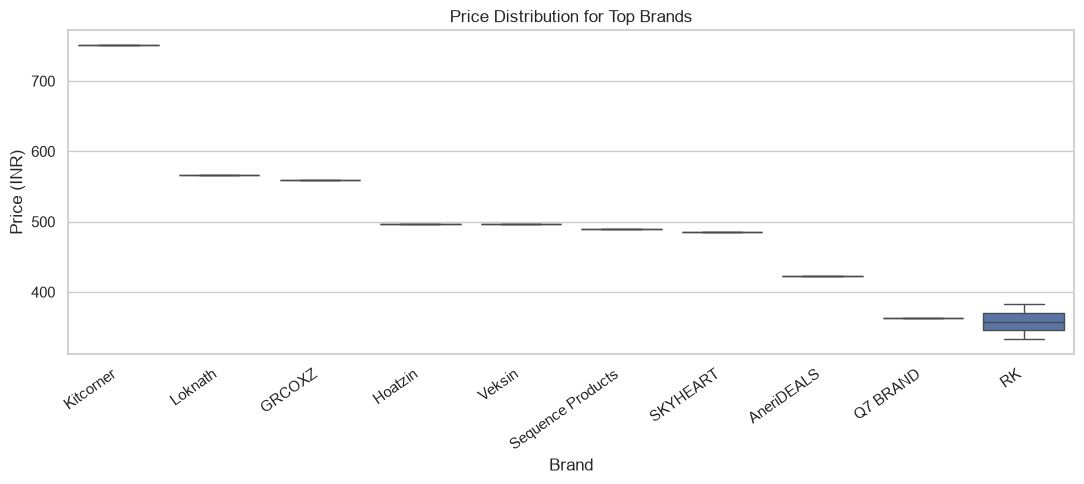

In [10]:
# Chart 7: Price distribution by brand
brand_order = df.groupby("Brand")["Price"].median().nlargest(10).index
plt.figure(figsize=(11, 5))
sns.boxplot(data=df[df["Brand"].isin(brand_order)], x="Brand", y="Price", order=brand_order)
plt.title("Price Distribution for Top Brands")
plt.xlabel("Brand")
plt.ylabel("Price (INR)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

<div align="center">

### Average Discount by Brand

**Comparing the average discount offered by different brands.**

</div>

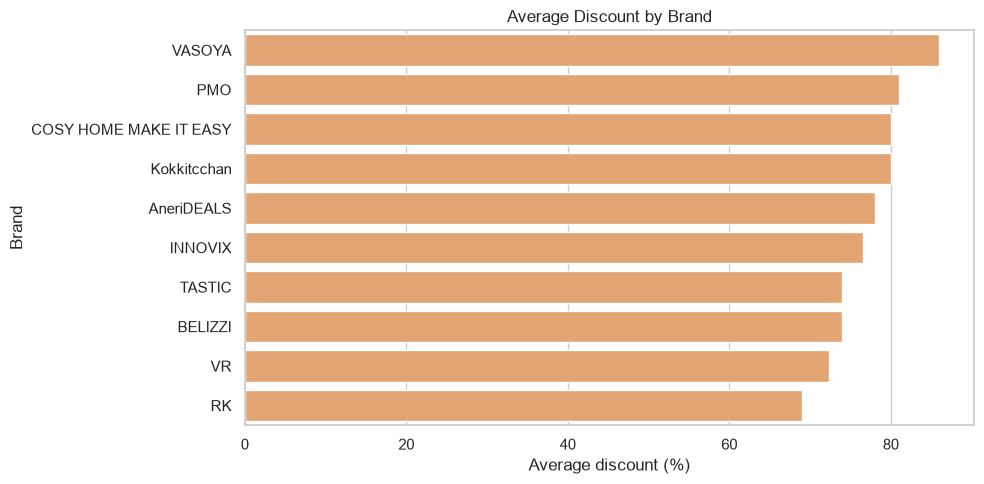

In [ ]:

brand_discount = (
    df.groupby("Brand", as_index=False)["Discount"]
    .mean()
    .sort_values("Discount", ascending=False)
    .head(10)
)
plt.figure(figsize=(10, 5))
sns.barplot(data=brand_discount, x="Discount", y="Brand", color="#f4a261")
plt.title("Average Discount by Brand")
plt.xlabel("Average discount (%)")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

<div align="center">

### Products by Capacity

**Analyzing the number of products across different capacity categories.**

</div>

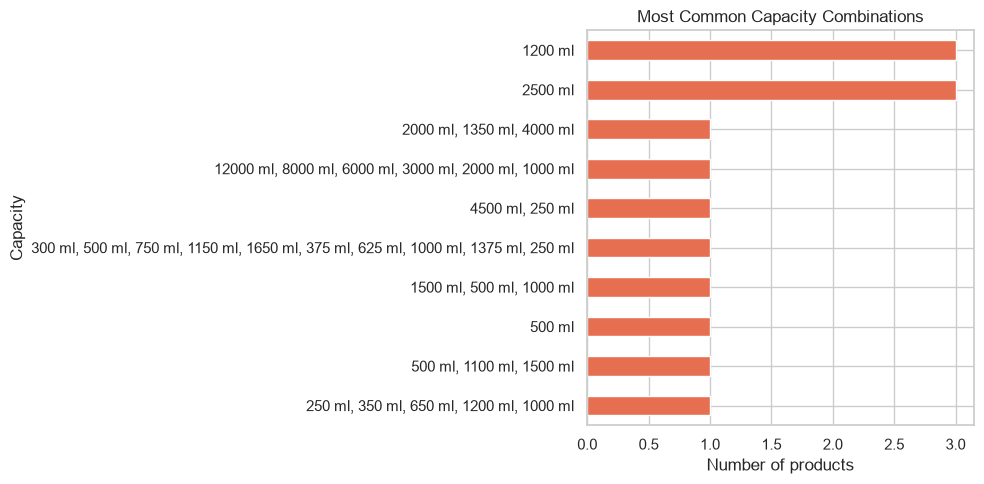

In [ ]:

capacity_counts = (
    df["Capacity"].fillna("Not specified").value_counts().head(10)
)
plt.figure(figsize=(10, 5))
capacity_counts.sort_values().plot(kind="barh", color="#e76f51")
plt.title("Most Common Capacity Combinations")
plt.xlabel("Number of products")
plt.ylabel("Capacity")
plt.tight_layout()
plt.show()

<div align="center">

### Chart 10: Products by Material

**Analyzing the number of products across different material categories.**

</div>

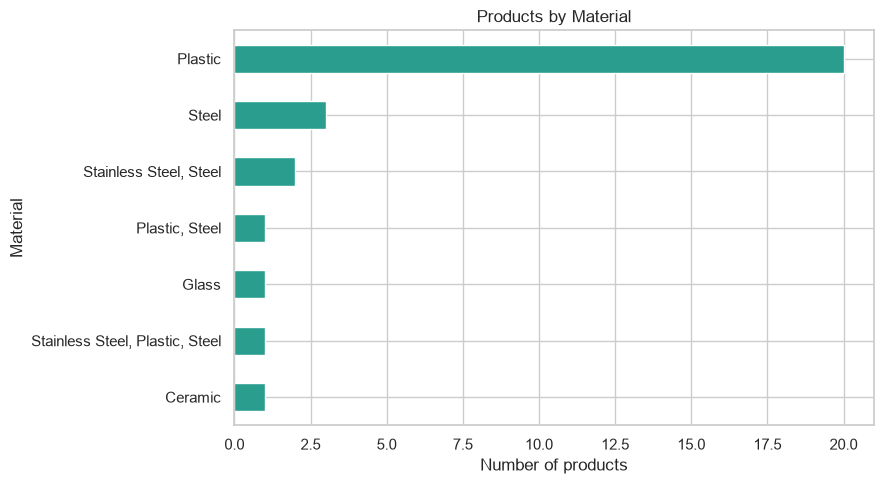

In [ ]:

material_counts = df["Material"].value_counts().head(10)
plt.figure(figsize=(9, 5))
material_counts.sort_values().plot(kind="barh", color="#2a9d8f")
plt.title("Products by Material")
plt.xlabel("Number of products")
plt.ylabel("Material")
plt.tight_layout()
plt.show()

<div align="center">

###  Conclusion

**Visualizations highlight key patterns in product pricing, ratings, discounts, reviews, brands, capacity, and materials.**

**These insights support better product comparison and data-driven business decisions.**

</div>